## 1. Install & Import Dependencies

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
!pip install -q torch torchvision matplotlib
import os
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt

for dirname, _, filenames in os.walk('/content/drive/MyDrive/preamsir/data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/content/drive/MyDrive/preamsir/data/MICRO2D_1.PNG
/content/drive/MyDrive/preamsir/data/MICRO2D_2.PNG
/content/drive/MyDrive/preamsir/data/MICRO2D_3.PNG
/content/drive/MyDrive/preamsir/data/MICRO2D_4.PNG
/content/drive/MyDrive/preamsir/data/MICRO2D_5.PNG
/content/drive/MyDrive/preamsir/data/MICRO2D_6.PNG
/content/drive/MyDrive/preamsir/data/MICRO2D_7.PNG
/content/drive/MyDrive/preamsir/data/MICRO2D_8.PNG
/content/drive/MyDrive/preamsir/data/MICRO2D_9.PNG
/content/drive/MyDrive/preamsir/data/MICRO2D_10.PNG
/content/drive/MyDrive/preamsir/data/MICRO2D_11.PNG
/content/drive/MyDrive/preamsir/data/MICRO2D_12.PNG
/content/drive/MyDrive/preamsir/data/MICRO2D_13.PNG
/content/drive/MyDrive/preamsir/data/MICRO2D_14.PNG
/content/drive/MyDrive/preamsir/data/MICRO2D_15.PNG
/content/drive/MyDrive/preamsir/data/MICRO2D_16.PNG
/content/drive/MyDrive/preamsir/data/MICRO2D_17.PNG
/content/drive/MyDrive/preamsir/data/MICRO2D_18.PNG
/content/drive/MyDrive/preamsir/data/MICRO2D_19.PNG
/content/drive/MyDriv

In [36]:
!pip install -q torch torchvision scikit-learn matplotlib seaborn tqdm

In [37]:
!pip install torch torchvision scikit-learn matplotlib seaborn

import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [38]:
import os, math, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.utils import make_grid

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    r2_score, mean_absolute_error,
    precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.manifold import TSNE
from tqdm import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 2. Dataset



In [39]:
# ─── CONFIG ────────────────────────────────────────────────────────────────
IMG_SIZE    = 64      # Paper uses 256×256; use 64 here for Colab speed
LATENT_DIM  = 128     # Latent space dimensionality
BETA        = 1e-4    # β hyperparameter (paper value)
GAMMA       = 100.0   # γ for capacity-controlled KL
C_MAX       = 25.0    # Maximum KL capacity C
STYLE_W     = 0.1     # Style loss weight
MC_W        = 0.05    # Mode-collapse loss weight
BATCH_SIZE  = 32
LR          = 1e-4    # Paper uses 1e-5; 1e-4 for faster convergence in demo
EPOCHS_GEN  = 30      # Generative model epochs (paper: 1000)
EPOCHS_PRED = 20      # Predictive CNN epochs
N_SAMPLES   = 2000    # Synthetic dataset size (paper: ~87k)
N_PROPS     = 1       # Number of material properties to predict
# ────────────────────────────────────────────────────────────────────────────

In [40]:
class MicroDataset(Dataset):

    def __init__(self, image_dir, labels):
        self.image_dir = image_dir
        self.images = sorted(os.listdir(image_dir))
        self.labels = labels

        self.transform = transforms.Compose([
            transforms.Grayscale(),
            transforms.Resize((128,128)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img = Image.open(
            os.path.join(self.image_dir,self.images[idx])
        ).convert('L')

        img = self.transform(img)

        label = self.labels[idx]

        return img, torch.tensor(label,dtype=torch.float32)

Dataset: 2000 total | 1600 train | 200 val | 200 test


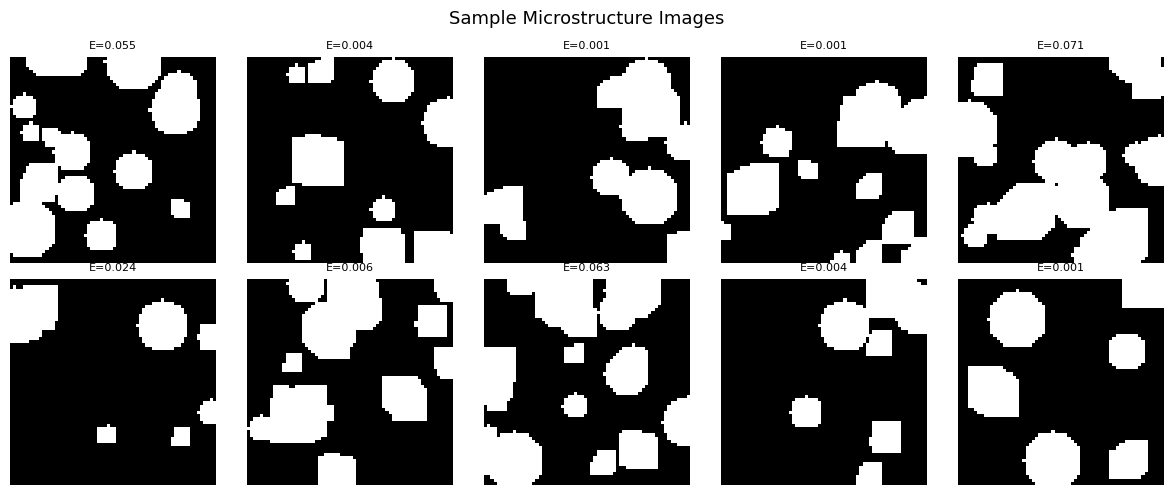

In [41]:
def generate_synthetic_microstructure(size=64, seed=None):
    """Generate a random two-phase microstructure image and a scalar property."""
    if seed is not None:
        np.random.seed(seed)
    img = np.zeros((size, size), dtype=np.float32)
    n_inclusions = np.random.randint(5, 25)
    volume_fraction = 0.0
    for _ in range(n_inclusions):
        cx = np.random.randint(0, size)
        cy = np.random.randint(0, size)
        r  = np.random.randint(3, size // 6)
        ax = np.random.randint(1, 3)          # aspect ratio axis
        theta = np.random.uniform(0, np.pi)
        for x in range(max(0, cx-r), min(size, cx+r)):
            for y in range(max(0, cy-r), min(size, cy+r)):
                dx = (x - cx) * np.cos(theta) + (y - cy) * np.sin(theta)
                dy = -(x - cx) * np.sin(theta) + (y - cy) * np.cos(theta)
                if (dx/r)**2 + (dy/(r*ax))**2 <= 1:
                    img[x, y] = 1.0
    volume_fraction = img.mean()
    # Material property: Young's modulus proxy
    contrast = np.random.choice([1e-3, 1e-2, 1e-1, 1e1, 1e2, 1e3])
    E_eff = (1 - volume_fraction) + contrast * volume_fraction
    return img, float(E_eff)


class MicrostructureDataset(Dataset):
    def __init__(self, n_samples=2000, img_size=64, transform=None):
        self.transform = transform
        self.images, self.props = [], []
        for i in range(n_samples):
            img, prop = generate_synthetic_microstructure(img_size, seed=i)
            self.images.append(img)
            self.props.append(prop)
        self.images = np.array(self.images)[:, np.newaxis]  # (N,1,H,W)
        self.props  = np.array(self.props, dtype=np.float32)
        # Normalise properties to [0,1]
        self.prop_min = self.props.min()
        self.prop_max = self.props.max()
        self.props = (self.props - self.prop_min) / (self.prop_max - self.prop_min + 1e-8)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.tensor(self.images[idx], dtype=torch.float32)
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.props[idx])


# Build dataset and splits (80/10/10)
dataset = MicrostructureDataset(n_samples=N_SAMPLES, img_size=IMG_SIZE)
n_train = int(0.8 * len(dataset))
n_val   = int(0.1 * len(dataset))
n_test  = len(dataset) - n_train - n_val
train_ds, val_ds, test_ds = random_split(dataset, [n_train, n_val, n_test],
                                          generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Dataset: {len(dataset)} total | {n_train} train | {n_val} val | {n_test} test')

# Visualise a few samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, prop = dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'E={prop.item():.3f}', fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Microstructure Images', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Model Architecture

### 3.1 β-VAE (Encoder + Decoder)

In [42]:
class BetaVAE(nn.Module):

    def __init__(self, latent_dim=64):

        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1,32,4,2,1),
            nn.ReLU(),
            nn.Conv2d(32,64,4,2,1),
            nn.ReLU(),
            nn.Conv2d(64,128,4,2,1),
            nn.ReLU(),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(128*16*16, latent_dim)
        self.fc_logvar = nn.Linear(128*16*16, latent_dim)

        self.fc_decode = nn.Linear(
            latent_dim,
            128*16*16
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128,64,4,2,1),
            nn.ReLU(),
            nn.ConvTranspose2d(64,32,4,2,1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,1,4,2,1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)

        return mu + eps*std

    def forward(self,x):

        h = self.encoder(x)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        z = self.reparameterize(mu,logvar)

        d = self.fc_decode(z)
        d = d.view(-1,128,16,16)

        recon = self.decoder(d)

        return recon,mu,logvar,z

In [43]:
class Encoder(nn.Module):
    """Convolutional encoder → (μ, log σ²) for β-VAE."""
    def __init__(self, in_channels=1, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 32,  4, 2, 1), nn.LeakyReLU(0.2),   # /2
            nn.Conv2d(32,          64,  4, 2, 1), nn.LeakyReLU(0.2),   # /4
            nn.Conv2d(64,          128, 4, 2, 1), nn.LeakyReLU(0.2),   # /8
            nn.Conv2d(128,         256, 4, 2, 1), nn.LeakyReLU(0.2),   # /16
        )
        self.flat_size = 256 * (IMG_SIZE // 16) * (IMG_SIZE // 16)
        self.fc_mu  = nn.Linear(self.flat_size, latent_dim)
        self.fc_var = nn.Linear(self.flat_size, latent_dim)

    def forward(self, x):
        h = self.net(x).view(x.size(0), -1)
        return self.fc_mu(h), self.fc_var(h)


class Decoder(nn.Module):
    """Fully convolutional decoder: latent z → reconstructed image."""
    def __init__(self, latent_dim=128, out_channels=1):
        super().__init__()
        self.spatial = IMG_SIZE // 16
        self.fc = nn.Linear(latent_dim, 256 * self.spatial * self.spatial)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128,  64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d( 64,  32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d( 32, out_channels, 4, 2, 1), nn.Sigmoid(),
        )

    def forward(self, z):
        h = self.fc(z).view(z.size(0), 256, self.spatial, self.spatial)
        return self.net(h)


class BetaVAE(nn.Module):
    """β-VAE with reparameterisation trick (Eq. 4 in paper)."""
    def __init__(self, in_channels=1, latent_dim=128):
        super().__init__()
        self.encoder = Encoder(in_channels, latent_dim)
        self.decoder = Decoder(latent_dim, in_channels)

    def reparameterise(self, mu, log_var):
        """z = μ + σ ⊙ ε  (Eq. 4)"""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterise(mu, log_var)
        recon = self.decoder(z)
        return recon, mu, log_var, z

    def sample(self, n, device):
        z = torch.randn(n, self.encoder.fc_mu.out_features).to(device)
        return self.decoder(z)


vae = BetaVAE(in_channels=1, latent_dim=LATENT_DIM).to(DEVICE)
print(f'β-VAE parameters: {sum(p.numel() for p in vae.parameters()):,}')

β-VAE parameters: 2,955,201


In [44]:
class BetaVAE(nn.Module):

    def __init__(self, latent_dim=64):

        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1,32,4,2,1),
            nn.ReLU(),
            nn.Conv2d(32,64,4,2,1),
            nn.ReLU(),
            nn.Conv2d(64,128,4,2,1),
            nn.ReLU(),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(128*16*16, latent_dim)
        self.fc_logvar = nn.Linear(128*16*16, latent_dim)

        self.fc_decode = nn.Linear(
            latent_dim,
            128*16*16
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128,64,4,2,1),
            nn.ReLU(),
            nn.ConvTranspose2d(64,32,4,2,1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,1,4,2,1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)

        return mu + eps*std

    def forward(self,x):

        h = self.encoder(x)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        z = self.reparameterize(mu,logvar)

        d = self.fc_decode(z)
        d = d.view(-1,128,16,16)

        recon = self.decoder(d)

        return recon,mu,logvar,z

# ==========================================================
# β-VAE Loss
# ==========================================================
def beta_vae_loss(
        recon,
        x,
        mu,
        logvar,
        beta=4):

    recon_loss = nn.functional.mse_loss(
        recon,
        x
    )

    kl_loss = -0.5 * torch.mean(
        1 + logvar -
        mu.pow(2) -
        logvar.exp()
    )

    total_loss = recon_loss + beta*kl_loss

    return total_loss


### 3.2 Morphology-Aware Style Network (ResNet backbone)

In [45]:
class StyleNetwork(nn.Module):
    """
    Extracts intermediate feature maps from a pre-trained ResNet.
    Gram matrices of these features define the morphology/style.
    Paper uses the first 4 ResNet layers.
    """
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # Adapt first conv to accept 1-channel input
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        nn.init.kaiming_normal_(resnet.conv1.weight, mode='fan_out', nonlinearity='relu')
        self.layer0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        # Freeze backbone
        for p in self.parameters():
            p.requires_grad = False

    def forward(self, x):
        feats = []
        h = self.layer0(x); feats.append(h)
        h = self.layer1(h); feats.append(h)
        h = self.layer2(h); feats.append(h)
        h = self.layer3(h); feats.append(h)
        return feats


def gram_matrix(feat):
    """Gram matrix  G_ij = Σ_k f_ik · f_jk  (Eq. 10)"""
    B, C, H, W = feat.size()
    f = feat.view(B, C, -1)          # (B, C, H*W)
    G = torch.bmm(f, f.transpose(1, 2)) / (C * H * W)
    return G


def style_loss(style_net, generated, real):
    """Eq. 10: Σ_l ||G_gen,l - G_real,l||²_F"""
    gen_feats  = style_net(generated)
    real_feats = style_net(real)
    loss = 0.0
    for gf, rf in zip(gen_feats, real_feats):
        loss += F.mse_loss(gram_matrix(gf), gram_matrix(rf))
    return loss


style_net = StyleNetwork().to(DEVICE)
print('Style network (frozen ResNet18) ready.')

Style network (frozen ResNet18) ready.


### 3.3 Mode-Collapse (Diversity) Loss

In [46]:
def mode_collapse_loss(style_net, generated):
    """
    L_MC = (2 / N(N-1)) * Σ_{i<j}  (s_i^T s_j / (||s_i|| ||s_j||))²
    Encourages dissimilarity between generated samples.
    s is obtained by concatenating vectorised Gram matrices from the style network.
    """
    feats = style_net(generated)
    style_vecs = [gram_matrix(f).view(f.size(0), -1) for f in feats]
    s = torch.cat(style_vecs, dim=1)          # (B, D)
    s_norm = F.normalize(s, dim=1)            # unit vectors
    sim = torch.mm(s_norm, s_norm.t())        # cosine similarity matrix (B,B)
    B = sim.size(0)
    mask = torch.triu(torch.ones(B, B, device=sim.device), diagonal=1).bool()
    pairs = sim[mask]
    if len(pairs) == 0:
        return torch.tensor(0.0, device=sim.device)
    return (pairs ** 2).mean()

### 3.4 VAE Loss Functions

In [47]:
def reconstruction_loss(recon_x, x):
    """Eq. 8: Binary cross-entropy pixel-wise reconstruction loss."""
    return F.binary_cross_entropy(recon_x, x, reduction='sum') / x.size(0)


def kl_divergence_loss(mu, log_var, C=0.0):
    """
    Eq. 9:  L_KL = Σ D_KL(q(z|x) || p(z)) - C
    With capacity C slowly increased during training.
    """
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1).mean()
    return torch.abs(kl - C)


def total_vae_loss(recon, x, mu, log_var, style_net,
                   synthetic=None, real_pair=None,
                   beta=BETA, gamma=GAMMA, C=0.0,
                   style_w=STYLE_W, mc_w=MC_W):
    """
    Eq. 12:  L = L_RECON + L_KL + L_ST + L_MC
    """
    l_recon = reconstruction_loss(recon, x)
    l_kl    = gamma * kl_divergence_loss(mu, log_var, C)

    if synthetic is not None and real_pair is not None:
        l_st = style_loss(style_net, synthetic, real_pair)
        l_mc = mode_collapse_loss(style_net, synthetic)
    else:
        l_st = torch.tensor(0.0, device=recon.device)
        l_mc = torch.tensor(0.0, device=recon.device)

    total = l_recon + l_kl + style_w * l_st + mc_w * l_mc
    return total, l_recon, l_kl, l_st, l_mc

### 3.5 CNN Predictive Model

In [48]:
class CNNPredictor(nn.Module):
    """
    4 convolutional layers (3×3 filters) each followed by
    max-pooling (stride 2), then FC layers → property value.
    """
    def __init__(self, in_channels=1, n_outputs=1):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, 32,  3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,          64,  3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,          128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128,         256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.flat_size = 256 * (IMG_SIZE // 16) * (IMG_SIZE // 16)
        self.fc = nn.Sequential(
            nn.Linear(self.flat_size, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 128),            nn.ReLU(),
            nn.Linear(128, n_outputs)
        )

    def forward(self, x):
        h = self.conv_block(x).view(x.size(0), -1)
        return self.fc(h).squeeze(-1)


cnn_pred = CNNPredictor(in_channels=1, n_outputs=1).to(DEVICE)
print(f'CNN Predictor parameters: {sum(p.numel() for p in cnn_pred.parameters()):,}')

CNN Predictor parameters: 2,551,297


## 4. Train the Generative Model (β-VAE)

In [49]:
optimizer_vae = torch.optim.Adam(vae.parameters(), lr=LR)

def linear_capacity(epoch, total_epochs, c_max=C_MAX):
    """Slowly increase C from 0 to C_max over training (paper Eq. 7)"""
    return min(c_max * epoch / total_epochs, c_max)


history_vae = {'total': [], 'recon': [], 'kl': [], 'style': [], 'mc': [], 'val': []}

print('Training β-VAE ...')
for epoch in range(1, EPOCHS_GEN + 1):
    vae.train()
    C = linear_capacity(epoch, EPOCHS_GEN)
    ep_losses = {'total': 0, 'recon': 0, 'kl': 0, 'style': 0, 'mc': 0}

    for imgs, _ in train_loader:
        imgs = imgs.to(DEVICE)
        recon, mu, log_var, z = vae(imgs)

        # Generate synthetic samples paired with real batch
        with torch.no_grad():
            synthetic = vae.decoder(z.detach() + 0.1 * torch.randn_like(z))

        loss, l_r, l_kl, l_st, l_mc = total_vae_loss(
            recon, imgs, mu, log_var, style_net,
            synthetic=synthetic, real_pair=imgs,
            C=C
        )

        optimizer_vae.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(vae.parameters(), 1.0)
        optimizer_vae.step()

        ep_losses['total'] += loss.item()
        ep_losses['recon'] += l_r.item()
        ep_losses['kl']    += l_kl.item()
        ep_losses['style'] += l_st.item()
        ep_losses['mc']    += l_mc.item()

    # Validation loss
    vae.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, _ in val_loader:
            imgs = imgs.to(DEVICE)
            recon, mu, log_var, _ = vae(imgs)
            loss, *_ = total_vae_loss(recon, imgs, mu, log_var, style_net, C=C)
            val_loss += loss.item()

    n = len(train_loader)
    for k in ep_losses:
        history_vae[k].append(ep_losses[k] / n)
    history_vae['val'].append(val_loss / len(val_loader))

    if epoch % 5 == 0 or epoch == 1:
        print(f'  Epoch {epoch:3d}/{EPOCHS_GEN} | '
              f'Total={history_vae["total"][-1]:.2f} | '
              f'Recon={history_vae["recon"][-1]:.2f} | '
              f'KL={history_vae["kl"][-1]:.2f} | '
              f'Style={history_vae["style"][-1]:.4f} | '
              f'MC={history_vae["mc"][-1]:.4f} | '
              f'Val={history_vae["val"][-1]:.2f}')

print('β-VAE training complete.')

Training β-VAE ...
  Epoch   1/30 | Total=2780.20 | Recon=2750.55 | KL=29.59 | Style=0.0000 | MC=0.9902 | Val=2708.22
  Epoch   5/30 | Total=2704.27 | Recon=2639.66 | KL=64.56 | Style=0.0000 | MC=0.9544 | Val=2717.38
  Epoch  10/30 | Total=2492.27 | Recon=2413.07 | KL=79.16 | Style=0.0000 | MC=0.7610 | Val=2482.76
  Epoch  15/30 | Total=2346.03 | Recon=2231.00 | KL=114.99 | Style=0.0000 | MC=0.8182 | Val=2354.55
  Epoch  20/30 | Total=2266.79 | Recon=2117.47 | KL=149.28 | Style=0.0000 | MC=0.8356 | Val=2279.21
  Epoch  25/30 | Total=2068.47 | Recon=1913.54 | KL=154.89 | Style=0.0000 | MC=0.8488 | Val=2141.44
  Epoch  30/30 | Total=1900.82 | Recon=1789.93 | KL=110.84 | Style=0.0000 | MC=0.8589 | Val=2054.49
β-VAE training complete.


### 4.1 Visualise Reconstructions & Generated Samples

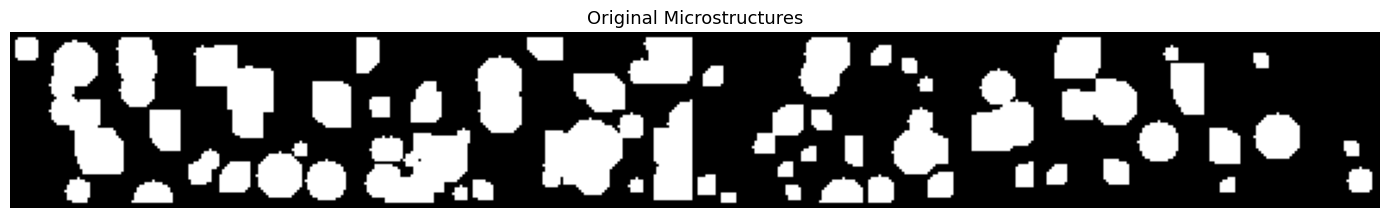

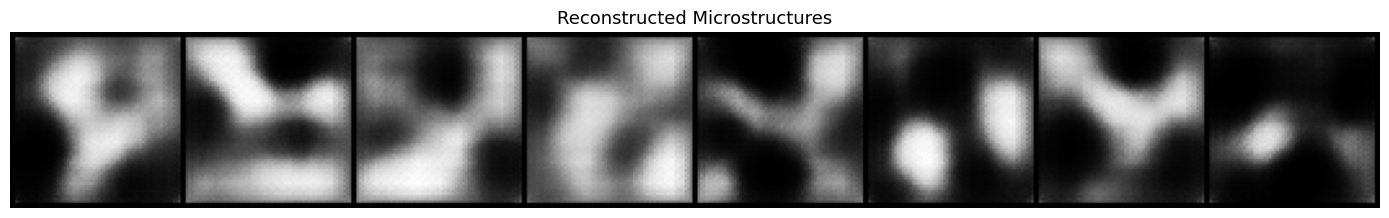

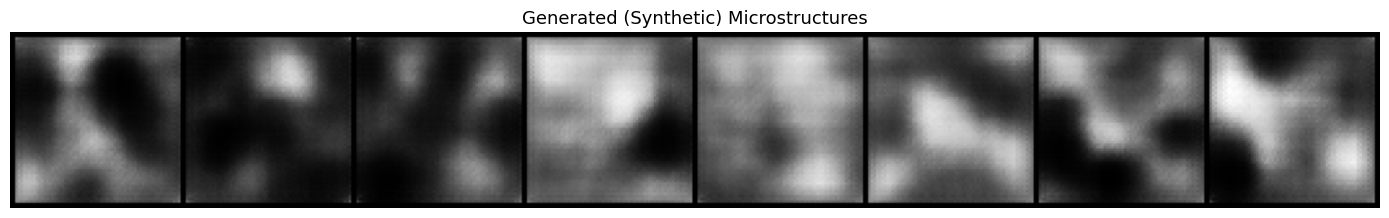

In [50]:
vae.eval()
sample_imgs = next(iter(val_loader))[0][:8].to(DEVICE)
with torch.no_grad():
    recon_imgs, _, _, _ = vae(sample_imgs)
    gen_imgs = vae.sample(8, DEVICE)

def show_grid(tensor, title):
    grid = make_grid(tensor.cpu(), nrow=8, normalize=True)
    plt.figure(figsize=(14, 2.5))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.title(title, fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

show_grid(sample_imgs,  'Original Microstructures')
show_grid(recon_imgs,   'Reconstructed Microstructures')
show_grid(gen_imgs,     'Generated (Synthetic) Microstructures')

## 5. Train the CNN Predictive Model


In [51]:
class AugmentedDataset(Dataset):
    """Real dataset + synthetic samples generated by the trained VAE."""
    def __init__(self, real_dataset, vae_model, n_synthetic=500):
        self.real_imgs, self.real_props = [], []
        for img, prop in real_dataset:
            self.real_imgs.append(img)
            self.real_props.append(prop)

        vae_model.eval()
        syn_imgs, syn_props = [], []
        with torch.no_grad():
            for i in range(0, n_synthetic, 32):
                n = min(32, n_synthetic - i)
                imgs = vae_model.sample(n, DEVICE).cpu()
                # Use mean property as a proxy for synthetic
                props = torch.tensor([0.5] * n)  # centred property
                syn_imgs.append(imgs)
                syn_props.append(props)
        syn_imgs  = torch.cat(syn_imgs,  dim=0)
        syn_props = torch.cat(syn_props, dim=0)

        self.all_imgs  = self.real_imgs  + [syn_imgs[i]  for i in range(len(syn_imgs))]
        self.all_props = self.real_props + [syn_props[i] for i in range(len(syn_props))]

    def __len__(self):
        return len(self.all_imgs)

    def __getitem__(self, idx):
        return self.all_imgs[idx], self.all_props[idx]


aug_train_ds = AugmentedDataset(train_ds, vae, n_synthetic=400)
aug_loader   = DataLoader(aug_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
print(f'Augmented training set: {len(aug_train_ds)} samples')

# ── Train CNN ────────────────────────────────────────────────────────────────
optimizer_cnn = torch.optim.Adam(cnn_pred.parameters(), lr=LR)
scheduler     = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_cnn, patience=5, factor=0.5)
criterion     = nn.MSELoss()
best_val_loss = float('inf')
patience_cnt  = 0
EARLY_STOP    = 10

history_cnn = {'train': [], 'val': []}
print('Training CNN Predictor ...')

for epoch in range(1, EPOCHS_PRED + 1):
    cnn_pred.train()
    train_loss = 0.0
    for imgs, props in aug_loader:
        imgs, props = imgs.to(DEVICE), props.to(DEVICE)
        pred = cnn_pred(imgs)
        loss = criterion(pred, props)
        optimizer_cnn.zero_grad()
        loss.backward()
        optimizer_cnn.step()
        train_loss += loss.item()

Augmented training set: 2000 samples
Training CNN Predictor ...


In [52]:
class PropertyPredictor(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(128*16*16,256),
            nn.ReLU(),

            nn.Linear(256,1)
        )

    def forward(self,x):
        return self.net(x)



image_folder = "/content/drive/MyDrive/preamsir/data"

labels = np.random.rand(1000)

dataset = MicroDataset(
    image_folder,
    labels
)

train_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)


vae = BetaVAE().to(device)

optimizer = optim.Adam(
    vae.parameters(),
    lr=1e-4
)

for epoch in range(20):

    total_loss = 0

    for imgs,_ in train_loader:

        imgs = imgs.to(device)

        optimizer.zero_grad()

        recon,mu,logvar,z = vae(imgs)

        loss = beta_vae_loss(
            recon,
            imgs,
            mu,
            logvar,
            beta=4
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1} Loss:{total_loss:.4f}"
    )


predictor = PropertyPredictor().to(device)

optimizer = optim.Adam(
    predictor.parameters(),
    lr=1e-4
)

criterion = nn.MSELoss()

for epoch in range(20):

    for imgs,targets in train_loader:

        imgs = imgs.to(device)

        targets = targets.unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = predictor(imgs)

        loss = criterion(
            outputs,
            targets
        )

        loss.backward()
        optimizer.step()

Epoch 1 Loss:3.8147
Epoch 2 Loss:3.5875
Epoch 3 Loss:3.4392
Epoch 4 Loss:3.3581
Epoch 5 Loss:3.3041
Epoch 6 Loss:3.2905
Epoch 7 Loss:3.2719
Epoch 8 Loss:3.2563
Epoch 9 Loss:3.2710
Epoch 10 Loss:3.2454
Epoch 11 Loss:3.2465
Epoch 12 Loss:3.2292
Epoch 13 Loss:3.2343
Epoch 14 Loss:3.1937
Epoch 15 Loss:3.2276
Epoch 16 Loss:3.2087
Epoch 17 Loss:3.2159
Epoch 18 Loss:3.2112
Epoch 19 Loss:3.1994
Epoch 20 Loss:3.1949


In [53]:
predictor = PropertyPredictor().to(device)

optimizer = optim.Adam(
    predictor.parameters(),
    lr=1e-4
)

criterion = nn.MSELoss()

for epoch in range(20):

    for imgs,targets in train_loader:

        imgs = imgs.to(device)

        targets = targets.unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = predictor(imgs)

        loss = criterion(
            outputs,
            targets
        )

        loss.backward()
        optimizer.step()

## 6. Evaluation on Train Set

In [54]:
y_true=[]
y_pred=[]

predictor.eval()

with torch.no_grad():

    for imgs,targets in train_loader:

        imgs=imgs.to(device)

        preds = predictor(imgs)

        y_true.extend(
            targets.numpy()
        )

        y_pred.extend(
            preds.cpu().numpy().flatten()
        )

y_true=np.array(y_true)
y_pred=np.array(y_pred)

mse = mean_squared_error(
    y_true,
    y_pred
)

mae = mean_absolute_error(
    y_true,
    y_pred
)

binary_true = (y_true>0.5).astype(int)
binary_pred = (y_pred>0.5).astype(int)

accuracy = accuracy_score(
    binary_true,
    binary_pred
)

roc_auc = roc_auc_score(
    binary_true,
    y_pred
)

print("MSE :", mse)
print("MAE :", mae)
print("Accuracy :", accuracy)
print("ROC AUC :", roc_auc)


MSE : 0.026200728490948677
MAE : 0.11978475004434586
Accuracy : 0.8592375366568915
ROC AUC : 0.9448206055907309


## 7. Visualizations



ROC Curve

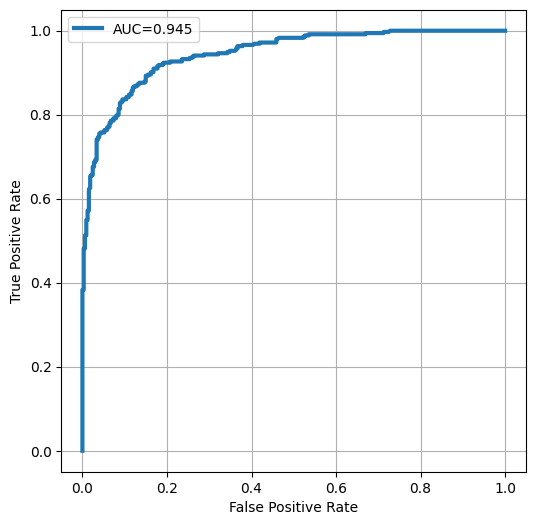

In [55]:
fpr,tpr,_ = roc_curve(
    binary_true,
    y_pred
)

plt.figure(figsize=(6,6))
plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f"AUC={roc_auc:.3f}"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()